In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score

# Load CSV
df = pd.read_csv(
    "/Users/joshpelayo/DATA 5322 02 Statistical Machine Learning 2/Final Project/GamingStudy_data_clean.csv",
    encoding="cp1252"
)

# Derived totals we DO NOT want to use in PCA
exclude_cols = [
    "GAD_T",
    "SPIN_T",
    "SWL_T",
    "S. No.",
    "Timestamp"
]

# Keep numeric columns only, excluding derived totals
numeric_df = df.select_dtypes(include=[np.number]).copy()

numeric_df = numeric_df.drop(
    columns=[col for col in exclude_cols if col in numeric_df.columns],
    errors="ignore"
)

# Optional: remove rows/columns that are mostly missing
numeric_df = numeric_df.loc[:, numeric_df.notna().sum() > 100]

feature_cols = numeric_df.columns.tolist()

print("Features used in PCA:")
print(feature_cols)

print("\nExcluded columns:")
print([col for col in exclude_cols if col in df.columns])

# Impute missing values
imputer = SimpleImputer(strategy="median")
X = imputer.fit_transform(numeric_df)

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Run PCA
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

# Explained variance
explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

for i, var in enumerate(explained_variance[:10], start=1):
    print(f"PC{i}: {var:.4f}")

print(f"\nCumulative variance from first 10 PCs: {cumulative_variance[9]:.4f}")

Features used in PCA:
['GAD1', 'GAD2', 'GAD3', 'GAD4', 'GAD5', 'GAD6', 'GAD7', 'SWL1', 'SWL2', 'SWL3', 'SWL4', 'SWL5', 'Hours', 'streams', 'SPIN1', 'SPIN2', 'SPIN3', 'SPIN4', 'SPIN5', 'SPIN6', 'SPIN7', 'SPIN8', 'SPIN9', 'SPIN10', 'SPIN11', 'SPIN12', 'SPIN13', 'SPIN14', 'SPIN15', 'SPIN16', 'SPIN17', 'Narcissism', 'Age']

Excluded columns:
['GAD_T', 'SPIN_T', 'SWL_T', 'S. No.', 'Timestamp']
PC1: 0.2845
PC2: 0.0961
PC3: 0.0650
PC4: 0.0414
PC5: 0.0373
PC6: 0.0322
PC7: 0.0304
PC8: 0.0289
PC9: 0.0271
PC10: 0.0249

Cumulative variance from first 10 PCs: 0.6679


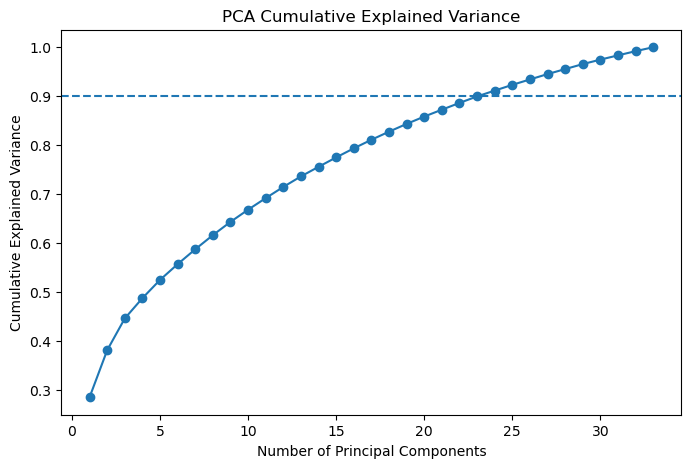

In [6]:
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker="o")
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Cumulative Explained Variance")
plt.axhline(0.90, linestyle="--")
plt.show()

In [7]:
n_components_90 = np.argmax(cumulative_variance >= 0.90) + 1
print("Number of PCs for 90% variance:", n_components_90)

pca_90 = PCA(n_components=n_components_90)
X_pca_90 = pca_90.fit_transform(X_scaled)

Number of PCs for 90% variance: 24


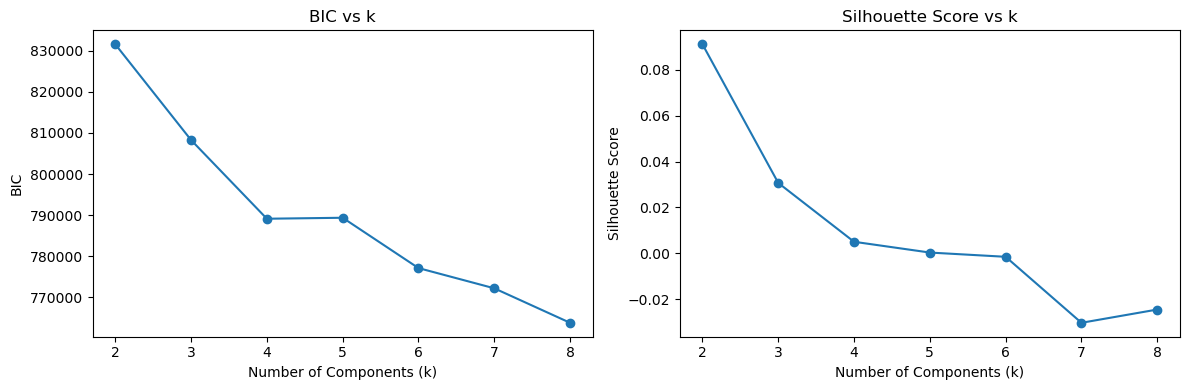

Best k by BIC: 8
Best k by Silhouette: 2


In [8]:
k_range = range(2, 9)
bic_scores = []
sil_scores = []

for k in k_range:
    gmm = GaussianMixture(n_components=k, random_state=42, n_init=5)
    labels = gmm.fit_predict(X_pca_90)

    bic_scores.append(gmm.bic(X_pca_90))
    sil_scores.append(silhouette_score(X_pca_90, labels))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(list(k_range), bic_scores, marker="o")
axes[0].set_xlabel("Number of Components (k)")
axes[0].set_ylabel("BIC")
axes[0].set_title("BIC vs k")

axes[1].plot(list(k_range), sil_scores, marker="o")
axes[1].set_xlabel("Number of Components (k)")
axes[1].set_ylabel("Silhouette Score")
axes[1].set_title("Silhouette Score vs k")

plt.tight_layout()
plt.show()

print(f"Best k by BIC: {list(k_range)[np.argmin(bic_scores)]}")
print(f"Best k by Silhouette: {list(k_range)[np.argmax(sil_scores)]}")